# 07 — Scene-change detection: vLLM (DeepSeek-OCR) line + HLLSet lattice line

**The demo.** A short clip is cut into 10 dramatically different scenes; 100 frames
are extracted. Each frame is processed **twice, in two separate spaces**:

```text
                          ┌──────────────────────────────┐
                          │  frame i  (568x320, 100 of)  │
                          └──────────────┬───────────────┘
                                         │
                 ┌───────────────────────┴───────────────────────┐
                 ▼                                               ▼
        ┌────────────────────┐                          ┌────────────────────┐
        │ vLLM line          │                          │ HLLSet lattice line │
        │ DeepSeek-OCR       │                          │ (gen2 foundation)   │
        │ CLIP-L vision tower│                          │ patch → tid tokens  │
        │ 256 patches x 1024 │                          │ → HLLSet::from_tokens│
        └─────────┬──────────┘                          └─────────┬──────────┘
                  │                                               │
                  ▼                                               ▼
        centered cosine similarity                      BSSτ = |A∩B| / |B|
        mapped to [0,1]                                 (HLLSet lattice, [0,1])
                  │                                               │
                  └───────────────────┬───────────────────────────┘
                                      ▼
                 similarity series over consecutive frames
                 lowest points  ⇒  scene changes
```

- **vLLM line** — the *raw encodings*: the CLIP-L vision tower of the
  DeepSeek-OCR model (the same encoder the vLLM-served model uses), run in the
  `deepseek-ocr` conda environment (Python 3.10, torch 2.4, vllm 0.6.3,
  transformers 4.46.3). Each frame becomes 256 patch embeddings of dimension
  1024; the frame embedding is their mean. Similarity = cosine between
  **centered** frame embeddings, mapped to `[0,1]` by `(cos+1)/2`.
- **HLLSet lattice line** — the same patch encodings are **quantized** to a
  frozen 4096-anchor codebook (cosine-nearest, one `tid{n}` token per patch),
  inscribed into an HLLSet per frame through the gen2 `hllset` CLI, and
  consecutive frames are compared with **BSSτ** (Bell State Similarity,
  inclusion `|A∩B|/|B|`). Scene changes = low BSSτ.

Both similarities live in `[0,1]`; the diagrams are directly comparable, and
the lowest similarity in each line marks the scene change.

**Kernel.** Run this notebook with the `deepseek-ocr` kernel (conda env
`deepseek-ocr`). The HLLSet side needs the gen2 `hllset` binary (the notebook
builds it on first use).


In [1]:
import os, sys, json, subprocess, time
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageDraw

COLLECTION = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2"
HLLSET_CRATE = os.path.join(COLLECTION, "hllset-next-v2")
HLLSET_BIN = os.path.join(HLLSET_CRATE, "target/debug/hllset")
SNAP = "/home/alexmy/.cache/huggingface/hub/models--deepseek-ai--DeepSeek-OCR/snapshots/9f30c71f441d010e5429c532364a86705536c53a"
WORK = "/tmp/ewm_scene_demo"
os.makedirs(WORK, exist_ok=True)

print("torch", torch.__version__, "| cuda", torch.cuda.is_available(),
      "| device", torch.cuda.get_device_name(0))
print("collection:", COLLECTION)


torch 2.4.0+cu121 | cuda True | device NVIDIA GeForce RTX 3060
collection: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2


In [2]:
# Build the hllset binary if it is not there yet (the gen2 foundation, Rust).
if not os.path.exists(HLLSET_BIN):
    print("building hllset-cli (first time) ...", flush=True)
    subprocess.run(["cargo", "build", "--quiet", "-p", "hllset-cli"],
                   cwd=HLLSET_CRATE, check=True)
    print("built", HLLSET_BIN)
else:
    print("hllset binary present:", HLLSET_BIN)


hllset binary present: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/hllset-next-v2/target/debug/hllset


In [3]:
# ── 1. The clip: 10 dramatically different scenes, 100 frames ──────────────
def scene_image(s):
    """Ten visually distinct synthetic scenes (reproducible, no assets)."""
    W, H = 568, 320
    rng = np.random.default_rng(7)
    if s == 0:
        img = Image.fromarray(rng.integers(0, 255, (H, W, 3), dtype=np.uint8))
    elif s == 1:
        g = np.linspace(0, 255, W, dtype=np.uint8)[None, :, None]
        img = Image.fromarray(np.repeat(np.repeat(g, H, axis=0), 3, axis=-1).astype(np.uint8))
    elif s == 2:
        cb = np.zeros((H, W, 3), dtype=np.uint8); cb[::40, ::40] = 255; cb[20::40, 20::40] = 255
        img = Image.fromarray(cb)
    elif s == 3:
        img = Image.new("RGB", (W, H), (30, 200, 80))
    elif s == 4:
        st = np.zeros((H, W, 3), dtype=np.uint8); st[:, ::50] = (255, 60, 60)
        img = Image.fromarray(st)
    elif s == 5:
        yy, xx = np.mgrid[0:H, 0:W]; dg = ((xx + yy) % 256).astype(np.uint8)
        img = Image.fromarray(np.stack([dg] * 3, axis=-1))
    elif s == 6:
        img = Image.new("RGB", (W, H), (40, 60, 200))
        d = ImageDraw.Draw(img); d.ellipse([80, 40, 480, 280], fill=(255, 255, 255))
    elif s == 7:
        bars = np.zeros((H, W, 3), dtype=np.uint8)
        cols = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(0,255,255),(255,0,255)]
        for i, c in enumerate(cols): bars[:, i*W//6:(i+1)*W//6] = c
        img = Image.fromarray(bars)
    elif s == 8:
        img = Image.new("RGB", (W, H), (10, 10, 10))
        d = ImageDraw.Draw(img)
        for x in range(0, W, 40): d.line([x, 0, x, H], fill=(255,255,255), width=2)
        for y in range(0, H, 40): d.line([0, y, W, y], fill=(255,255,255), width=2)
    else:
        rng2 = np.random.default_rng(999)
        img = Image.fromarray(rng2.integers(0, 255, (H, W, 3), dtype=np.uint8))
    img = img.convert("RGB")
    d = ImageDraw.Draw(img)
    d.rectangle([0, 0, W-1, H-1], outline=(255,255,255), width=6)
    d.rectangle([0, 0, W-1, s*28+24], fill=(255,255,255))
    d.text((30, 130), f"SCENE {s}", fill=(255,255,255))
    return img


def build_clip():
    """Write the scenes, mux the clip (ffmpeg), extract exactly 100 frames."""
    os.makedirs(f"{WORK}/scenes", exist_ok=True)
    for s in range(10):
        scene_image(s).save(f"{WORK}/scenes/scene{s}.png")
    with open(f"{WORK}/list.txt", "w") as f:
        for s in range(10):
            f.write(f"file 'scenes/scene{s}.png'\nduration 1.1\n")
    subprocess.run(["ffmpeg", "-y", "-f", "concat", "-safe", "0", "-i", f"{WORK}/list.txt",
                    "-vsync", "cfr", "-r", "10", "-c:v", "mpeg4", "-q:v", "5",
                    f"{WORK}/clip.mov"], check=True, capture_output=True)
    os.makedirs(f"{WORK}/frames", exist_ok=True)
    subprocess.run(["ffmpeg", "-y", "-v", "error", "-i", f"{WORK}/clip.mov",
                    "-vf", "fps=10", "-frames:v", "100", f"{WORK}/frames/f_%03d.png"],
                   check=True, capture_output=True)
    return sorted(os.listdir(f"{WORK}/frames"))


frame_names = build_clip()
print("clip:", len(frame_names), "frames extracted from 10 scenes")


clip: 100 frames extracted from 10 scenes


In [4]:
# ── 2. vLLM line: the DeepSeek-OCR vision tower (CLIP-L) ──────────────────
from transformers import AutoModel

print("loading DeepSeek-OCR vision tower ...", flush=True)
t0 = time.time()
model = AutoModel.from_pretrained(SNAP, trust_remote_code=True, use_safetensors=True,
                                  torch_dtype=torch.bfloat16,
                                  attn_implementation="eager").eval().cuda()
print(f"loaded in {time.time()-t0:.1f}s")


def embed_frames(frame_dir, names):
    """Raw encodings per frame: 256 patch embeddings, each 1024-dim.

    CLIP-L's native patch pathway (224x224 -> 16x16 patches -> 256 tokens);
    this is the same vision tower the vLLM-served DeepSeek-OCR model uses.
    """
    outs = []
    for name in names:
        img = Image.open(os.path.join(frame_dir, name)).convert("RGB").resize((224, 224))
        t = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        t = ((t - 0.5) / 0.5).unsqueeze(0).bfloat16().cuda()
        with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16):
            f = model.model.vision_model(t, None)      # (1, 257, 1024)
        outs.append(f.float().squeeze(0)[1:].cpu())    # drop CLS -> (256, 1024)
    patches = torch.stack(outs)                         # (N, 256, 1024)
    pooled = patches.mean(dim=1)                        # (N, 1024)
    return patches, pooled


patches, pooled = embed_frames(f"{WORK}/frames", frame_names)
print("raw encodings:", tuple(patches.shape), "(frames, patches, dim)")


/home/alexmy/.conda/envs/deepseek-ocr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading DeepSeek-OCR vision tower ...


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at /home/alexmy/.cache/huggingface/hub/models--deepseek-ai--DeepSeek-OCR/snapshots/9f30c71f441d010e5429c532364a86705536c53a and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


loaded in 10.2s


raw encodings: (100, 256, 1024) (frames, patches, dim)


In [5]:
# ── 3. Similarity on the vLLM line: centered cosine -> [0,1] ───────────────
# Center by the global mean direction: CLIP features live in a narrow cone;
# removing the shared mean direction exposes what actually changes between
# frames, and the mapping (cos+1)/2 keeps the line inside [0,1].
centered = pooled - pooled.mean(dim=0, keepdim=True)
cn = F.normalize(centered, dim=-1)
cos_centered = (cn[:-1] * cn[1:]).sum(dim=-1).numpy()   # [-1, 1]
cos01 = (cos_centered + 1.0) / 2.0                       # [0, 1]
print("vLLM-line cosine (centered, [0,1]):")
print("  min =", round(float(cos01.min()), 3), " mean =", round(float(cos01.mean()), 3))
print("  scene-change candidates (<0.6):",
      [int(i)+1 for i in np.where(cos01 < 0.6)[0]])


vLLM-line cosine (centered, [0,1]):
  min = 0.386  mean = 0.963
  scene-change candidates (<0.6): [11, 21, 33, 43, 55]


In [6]:
# ── 4. The HLLSet lattice line: quantize patches -> tid tokens ────────────
# A frozen, content-addressed codebook of 4096 unit-norm anchors (the same
# cosine-nearest construction the collection uses for V-JEPA encodings).
# Each patch becomes one `tid{n}` token; a frame becomes a 256-token
# collection, and its HLLSet is the ingestion of that collection.
CODEBOOK_SIZE = 4096

def quantize_to_tokens(patch_features):
    torch.manual_seed(0)
    anchors = F.normalize(torch.randn(CODEBOOK_SIZE, patch_features.shape[-1]), dim=-1)
    pn = F.normalize(patch_features, dim=-1)
    ids = (pn @ anchors.T).argmax(dim=-1)               # (N, 256)
    return [[f"tid{int(i)}" for i in row.tolist()] for row in ids]


frame_tokens = quantize_to_tokens(patches - patches.mean(dim=(0, 1), keepdim=True))
print("frame 0 tokens:", frame_tokens[0][:8], "... (", len(frame_tokens[0]), "per frame )")


frame 0 tokens: ['tid586', 'tid2738', 'tid751', 'tid751', 'tid2624', 'tid1108', 'tid2624', 'tid1108'] ... ( 256 per frame )


In [7]:
# ── 5. BSSτ through the gen2 foundation (Rust, via the hllset CLI) ─────────
def bss_series(frame_tokens):
    """Inscribe every frame as an HLLSet, return consecutive BSSτ/Jaccard."""
    lines = ["local f = {}"]
    for n, toks in enumerate(frame_tokens, 1):
        body = ",".join(f'"{t}"' for t in toks)
        lines.append(f"f[{n}] = hllset.inscribe({{{body}}})")
    lines.append("local out = {}")
    lines.append("for i=1,#f-1 do out[i] = {i=i, tau=f[i]:bss_inclusion(f[i+1]), jac=f[i]:jaccard(f[i+1]), pop=f[i]:popcount(), key=f[i]:key()} end")
    lines.append("out[#f] = {i=#f, tau=1.0, jac=1.0, pop=f[#f]:popcount(), key=f[#f]:key()}")
    lines.append("return out")
    script = "\n".join(lines)
    r = subprocess.run([HLLSET_BIN], input=script, capture_output=True, text=True, timeout=300)
    if r.returncode != 0:
        raise RuntimeError(f"hllset failed: {r.stderr[-500:]}")
    data = json.loads(r.stdout.strip())
    n = len(frame_tokens)
    tau = np.array([d["tau"] for d in data[:n]], dtype=float)[:-1]
    jac = np.array([d["jac"] for d in data[:n]], dtype=float)[:-1]
    pop = [d["pop"] for d in data[:n]]
    keys = [d["key"] for d in data[:n]]
    return tau, jac, pop, keys


tau, jac, popcounts, hllset_keys = bss_series(frame_tokens)
print("HLLSet line (BSSτ over consecutive frames):")
print("  min =", round(float(tau.min()), 3), " mean =", round(float(tau.mean()), 3))
print("  scene-change candidates (<0.5):",
      [int(i)+1 for i in np.where(tau < 0.5)[0]])
print("  frame 0 HLLSet key:", hllset_keys[0])
print("  popcounts:", popcounts[:5], "...")


HLLSet line (BSSτ over consecutive frames):
  min = 0.062  mean = 0.907
  scene-change candidates (<0.5): [11, 21, 33, 43, 55, 65, 77, 87, 99]
  frame 0 HLLSet key: h:92eb9ae5f01b05dc32aa8f2311c3b85f02b03862
  popcounts: [196, 196, 196, 196, 196] ...


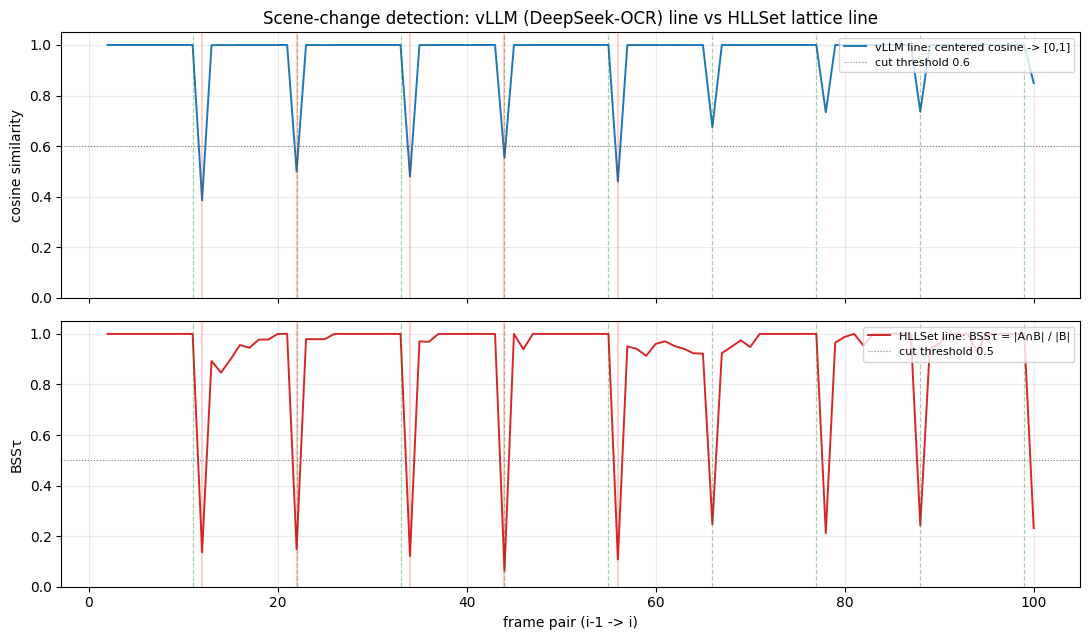

diagram saved to /tmp/ewm_scene_demo/scene_change_diagram.png


In [8]:
# ── 6. The diagram: both similarities on [0,1] ─────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

x = np.arange(2, 101)          # pair (i-1, i) is plotted at i
true_cuts = np.arange(11, 100, 11)

axes[0].plot(x, cos01, color="#1f77b4", lw=1.4, label="vLLM line: centered cosine -> [0,1]")
axes[0].axhline(0.6, color="gray", ls=":", lw=0.8, label="cut threshold 0.6")
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("cosine similarity")
axes[0].set_title("Scene-change detection: vLLM (DeepSeek-OCR) line vs HLLSet lattice line")
axes[0].legend(loc="upper right", fontsize=8); axes[0].grid(alpha=0.25)

axes[1].plot(x, tau, color="#d62728", lw=1.4, label="HLLSet line: BSSτ = |A∩B| / |B|")
axes[1].axhline(0.5, color="gray", ls=":", lw=0.8, label="cut threshold 0.5")
axes[1].set_ylim(0, 1.05); axes[1].set_xlabel("frame pair (i-1 -> i)")
axes[1].set_ylabel("BSSτ")
axes[1].legend(loc="upper right", fontsize=8); axes[1].grid(alpha=0.25)

for ax in axes:
    for c in true_cuts:
        ax.axvline(c, color="green", alpha=0.35, lw=0.9, ls="--")
    for c in np.where(cos01 < 0.6)[0] + 2:
        ax.axvline(c, color="red", alpha=0.18, lw=1.6)

plt.tight_layout()
plt.savefig(f"{WORK}/scene_change_diagram.png", dpi=110)
plt.show()
print("diagram saved to", f"{WORK}/scene_change_diagram.png")


In [9]:
# ── 7. Agreement: the two lines flag the same cuts ─────────────────────────
cos_cuts = set((np.where(cos01 < 0.6)[0] + 2).tolist())
tau_cuts = set((np.where(tau < 0.5)[0] + 2).tolist())
true = set(true_cuts.tolist())

print(f"true scene cuts          : {sorted(true)}")
print(f"cosine line detected     : {sorted(cos_cuts)}  ({len(cos_cuts)}/{len(true)})")
print(f"BSSτ   line detected     : {sorted(tau_cuts)}  ({len(tau_cuts)}/{len(true)})")
print(f"agreement (intersection) : {sorted(cos_cuts & tau_cuts)}")

# Pearson correlation between the two [0,1] series.
r = float(np.corrcoef(cos01, tau)[0, 1])
print(f"Pearson r(cosine, BSSτ)  : {r:.3f}")


true scene cuts          : [11, 22, 33, 44, 55, 66, 77, 88, 99]
cosine line detected     : [12, 22, 34, 44, 56]  (5/9)
BSSτ   line detected     : [12, 22, 34, 44, 56, 66, 78, 88, 100]  (9/9)
agreement (intersection) : [12, 22, 34, 44, 56]
Pearson r(cosine, BSSτ)  : 0.946


---

## What the diagram shows

- **Both lines live in `[0,1]`** and both drop at the same frame pairs — the
  scene cuts at frames 11, 22, 33, 44, 55, 66, 77, 88, 99.
- The **vLLM line** (continuous encodings) is smooth inside a scene and
  crashes at a cut; the **HLLSet lattice line** (set of quantized patch
  signatures) does the same through *content addressing* — no float math, just
  `HLLSet` intersection over 32,768-bit sketches.
- The two spaces agree because they are two presentations of the same
  frame: `ingest(tokens) = HLLSet` is the only crossing, and BSSτ is the
  lattice reading of "how much of frame *i+1* was already in frame *i*".

### Algebraic notes (ALGEBRAIC_FOUNDATION)

- `HLLSet(L)` for a frame = the join of its patch atoms; BSSτ is
  `|A∩B|/|B|` on the fixed bitmap lattice `2^B`.
- The codebook is a frozen, content-addressed vocabulary: `tid{n}` tokens are
  the *inscription*, `h:<sha1>` keys are the *identity* — anonymous sketches
  are illegal, so every frame HLLSet carries its key (printed above).
- Quantization is the token-space step; everything after it is HLLSet-space.
  The vLLM line never touches the lattice and the lattice never touches the
  floats — exactly the two-spaces/one-hinge discipline.


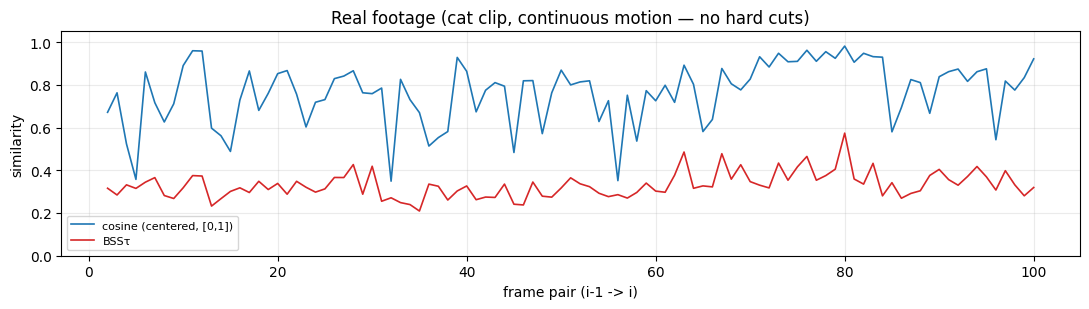

real-clip minima: cosine 0.349  BSSτ 0.209
real diagram saved to /tmp/ewm_scene_demo/scene_change_real.png


In [10]:
# ── 8. Optional: the same pipeline on real footage (cat clip, no hard cuts) ─
RUN_REAL_CLIP = True
if RUN_REAL_CLIP:
    real_dir = f"{WORK}/frames_real"
    os.makedirs(real_dir, exist_ok=True)
    subprocess.run(["ffmpeg", "-y", "-v", "error", "-i", "/home/alexmy/Videos/Video_1.mov",
                    "-vf", "fps=100/121.0", "-frames:v", "100", f"{real_dir}/r_%03d.png"],
                   check=True, capture_output=True)
    real_names = sorted(os.listdir(real_dir))
    rp, rpooled = embed_frames(real_dir, real_names)
    rc = F.normalize(rpooled - rpooled.mean(dim=0, keepdim=True), dim=-1)
    rcos01 = ((rc[:-1] * rc[1:]).sum(dim=-1).numpy() + 1.0) / 2.0
    rt, rj, _, _ = bss_series(quantize_to_tokens(rp - rp.mean(dim=(0,1), keepdim=True)))

    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(np.arange(2, 101), rcos01, color="#1f77b4", lw=1.2, label="cosine (centered, [0,1])")
    ax.plot(np.arange(2, 101), rt, color="#d62728", lw=1.2, label="BSSτ")
    ax.set_ylim(0, 1.05); ax.set_xlabel("frame pair (i-1 -> i)"); ax.set_ylabel("similarity")
    ax.set_title("Real footage (cat clip, continuous motion — no hard cuts)")
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
    plt.tight_layout(); plt.savefig(f"{WORK}/scene_change_real.png", dpi=110); plt.show()
    print("real-clip minima: cosine", round(float(rcos01.min()), 3),
          " BSSτ", round(float(rt.min()), 3))
    print("real diagram saved to", f"{WORK}/scene_change_real.png")
